In [1]:
!pip install feature-engine

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.4/276.4 kB 5.2 MB/s eta 0:00:00


## Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from feature_engine.imputation import MeanMedianImputer, ArbitraryNumberImputer

## Data Loading

In [3]:
cols_to_use = [
    'BsmtQual',
    'FireplaceQu',
    'LotFrontage',
    'MasVnrArea',
    'GarageYrBlt',
    'SalePrice',
]

train_df = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv', usecols=cols_to_use)

train_df.head()

,LotFrontage,MasVnrArea,BsmtQual,FireplaceQu,GarageYrBlt,SalePrice
0,65.0,196.0,Gd,NaN,2003.0,208500
1,80.0,0.0,Gd,TA,1976.0,181500
2,68.0,162.0,Gd,TA,2001.0,223500
3,60.0,0.0,TA,Gd,1998.0,140000
4,84.0,350.0,Gd,TA,2000.0,250000


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    train_df.drop('SalePrice', axis=1),
    train_df['SalePrice'],
    test_size=0.3,
    random_state=0,
)

X_train.shape, X_test.shape

((1022, 5), (438, 5))

In [5]:
X_train.isnull().mean()

LotFrontage    0.184932
MasVnrArea     0.004892
BsmtQual       0.023483
FireplaceQu    0.467710
GarageYrBlt    0.052838
dtype: float64

## Impute Numerical Values

In [6]:
imputer = MeanMedianImputer(imputation_method='median')

In [7]:
imputer.fit(X_train)

MeanMedianImputer()

In [8]:
imputer.variables_

['LotFrontage', 'MasVnrArea', 'GarageYrBlt']

In [9]:
imputer.imputer_dict_

{'LotFrontage': 69.0, 'MasVnrArea': 0.0, 'GarageYrBlt': 1979.0}

In [10]:
X_train_t = imputer.transform(X_train)
X_test_t = imputer.transform(X_test)

X_train_t.head()

,LotFrontage,MasVnrArea,BsmtQual,FireplaceQu,GarageYrBlt
64,69.0,573.0,Gd,NaN,1998.0
682,69.0,0.0,Gd,Gd,1996.0
960,50.0,0.0,TA,NaN,1979.0
1384,60.0,0.0,TA,NaN,1939.0
1100,60.0,0.0,TA,NaN,1930.0


In [11]:
X_train_t[imputer.variables_].isnull().mean()

LotFrontage    0.0
MasVnrArea     0.0
GarageYrBlt    0.0
dtype: float64

In [12]:
imputer = MeanMedianImputer(
    imputation_method='mean',
    variables=['LotFrontage', 'MasVnrArea'],
)

imputer.fit(X_train)

MeanMedianImputer(imputation_method='mean',
                  variables=['LotFrontage', 'MasVnrArea'])

In [13]:
imputer.variables_

['LotFrontage', 'MasVnrArea']

In [14]:
imputer.imputer_dict_

{'LotFrontage': 69.66866746698679, 'MasVnrArea': 103.55358898721731}

In [15]:
X_train[imputer.variables_].mean()

LotFrontage     69.668667
MasVnrArea     103.553589
dtype: float64

In [16]:
X_train_t = imputer.transform(X_train)
X_test_t = imputer.transform(X_test)

X_train_t[imputer.variables_].isnull().mean()

LotFrontage    0.0
MasVnrArea     0.0
dtype: float64

In [17]:
pipe = Pipeline(
    [
        (
            'median_imputer',
            MeanMedianImputer(
                imputation_method='median', variables=['LotFrontage', 'GarageYrBlt']
            ),
        ),
        (
            'mean_imputer',
            MeanMedianImputer(imputation_method='mean', variables=['MasVnrArea']),
        ),
    ]
)

In [18]:
pipe.fit(X_train)

Pipeline(steps=[('median_imputer',
                 MeanMedianImputer(variables=['LotFrontage', 'GarageYrBlt'])),
                ('mean_imputer',
                 MeanMedianImputer(imputation_method='mean',
                                   variables=['MasVnrArea']))])

In [19]:
pipe.named_steps['median_imputer'].imputer_dict_

{'LotFrontage': 69.0, 'GarageYrBlt': 1979.0}

In [20]:
pipe.named_steps['mean_imputer'].imputer_dict_

{'MasVnrArea': 103.55358898721731}

In [21]:
X_train_t = pipe.transform(X_train)
X_test_t = pipe.transform(X_test)

X_train_t.isnull().mean()

LotFrontage    0.000000
MasVnrArea     0.000000
BsmtQual       0.023483
FireplaceQu    0.467710
GarageYrBlt    0.000000
dtype: float64

## Arbitrary Imputation

In [22]:
# imputer = ArbitraryNumberImputer(arbitrary_number=-999)

imputer = ArbitraryNumberImputer(
    imputer_dict={
        'LotFrontage': -999,
        'MasVnrArea': -999,
        'GarageYrBlt': -1
    }
)

In [23]:
imputer.fit(X_train)

ArbitraryNumberImputer(imputer_dict={'GarageYrBlt': -1, 'LotFrontage': -999,
                                     'MasVnrArea': -999})

In [24]:
imputer.variables_

dict_keys(['LotFrontage', 'MasVnrArea', 'GarageYrBlt'])

In [25]:
imputer.arbitrary_number

999

In [26]:
X_train_t = imputer.transform(X_train)
X_test_t = imputer.transform(X_test)

X_train_t.head()

,LotFrontage,MasVnrArea,BsmtQual,FireplaceQu,GarageYrBlt
64,-999.0,573.0,Gd,NaN,1998.0
682,-999.0,0.0,Gd,Gd,1996.0
960,50.0,0.0,TA,NaN,-1.0
1384,60.0,0.0,TA,NaN,1939.0
1100,60.0,0.0,TA,NaN,1930.0


In [27]:
X_train_t[imputer.variables_].isnull().mean()

LotFrontage    0.0
MasVnrArea     0.0
GarageYrBlt    0.0
dtype: float64

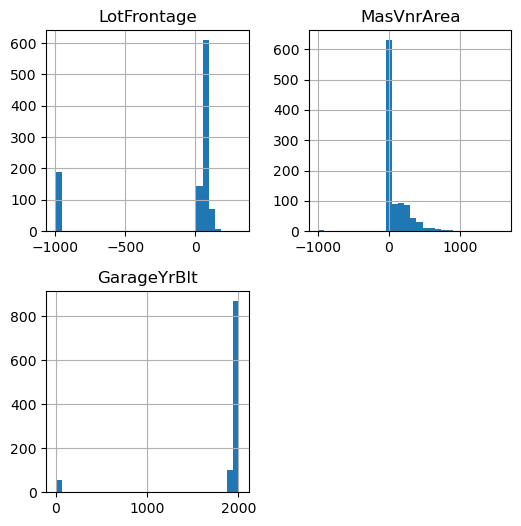

In [28]:
X_train_t[imputer.variables_].hist(bins=30, figsize=(6, 6))
plt.show()

## Frequent Category Imputation

In [29]:
from feature_engine.imputation import CategoricalImputer

In [30]:
cols_to_use = [
    'BsmtQual',
    'FireplaceQu',
    'LotFrontage',
    'MasVnrArea',
    'GarageYrBlt',
    'SalePrice',
]

train_df = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv', usecols=cols_to_use)

train_df.head()

,LotFrontage,MasVnrArea,BsmtQual,FireplaceQu,GarageYrBlt,SalePrice
0,65.0,196.0,Gd,NaN,2003.0,208500
1,80.0,0.0,Gd,TA,1976.0,181500
2,68.0,162.0,Gd,TA,2001.0,223500
3,60.0,0.0,TA,Gd,1998.0,140000
4,84.0,350.0,Gd,TA,2000.0,250000


In [31]:
imputer = CategoricalImputer(imputation_method='frequent')

# imputer = CategoricalImputer(imputation_method='frequent', variables=['FireplaceQu', 'BsmtQual'])

In [32]:
imputer.fit(X_train)

CategoricalImputer(imputation_method='frequent')

In [33]:
imputer.variables_

['BsmtQual', 'FireplaceQu']

In [34]:
X_train_t = imputer.transform(X_train)
X_test_t = imputer.transform(X_test)

X_train_t.head()

,LotFrontage,MasVnrArea,BsmtQual,FireplaceQu,GarageYrBlt
64,NaN,573.0,Gd,Gd,1998.0
682,NaN,0.0,Gd,Gd,1996.0
960,50.0,0.0,TA,Gd,NaN
1384,60.0,0.0,TA,Gd,1939.0
1100,60.0,0.0,TA,Gd,1930.0


In [35]:
X_train_t.isnull().mean()

LotFrontage    0.184932
MasVnrArea     0.004892
BsmtQual       0.000000
FireplaceQu    0.000000
GarageYrBlt    0.052838
dtype: float64